# VLE from fugacity calculation

Use the Generalized Peng-Robinson equation of state to calculate the vapor-liquid equilibrium curve. We will need to evaluate the Peng-Robinson EOS and use the Peng-Robinson form of the fugacity equation.

This notebook shows how I developed preliminary calcuations before generating the final plots. 

Eric Furst, December 2025

## Generalized Peng-Robinson Equation of State

Routines to calcualte the Generalized Peng-Robinson Equation of State

SIS is Stanley I. Sandler, *Chemical, Biochemcial and Engineering Thermodynamics*, 5th ed.

Eric Furst, November 2025

The Generalized Peng-Robinson equation of state is

$$ P = \frac{RT}{\underline{V}-b} - \frac{a(T)}{\underline{V}(\underline{V}+b) + b(\underline{V}-b)} \tag{Eq. 6.4-2}$$

with

$$ b = 0.07780 \frac{RT_c}{P_c} \tag{Eq. 6.7-2}$$
$$ a(T) = a(T_c)\alpha(T) = 0.45724 \frac{R^2T_c^2}{P_c}\alpha(T) \tag{Eq. 6.7-1}$$
$$ \sqrt{\alpha} = 1 + \kappa \left ( 1- \sqrt{\frac{T}{T_c}} \right ) \tag{Eq. 6.7-3}$$
$$ \kappa = 0.37464 + 1.54226\omega − 0.26992\omega^2 \tag{Eq. 6.7-4}$$

The acentric factor $\omega$ and the crticial temperatures and pressures are given in SIS table 6.6-1.

Calculating the pressure $P$ given $\underline{V}$ and $T$ is straightforward, but to calculate the molar volume given $P$ and $T$, we need to solve the cubic equation of state of the form

$$ Z^3 + \alpha Z^2 + \beta Z + \gamma = 0 \tag{Eq. 6.4-4}$$

where $Z$ is the compressibility factor

$$ Z = \frac{P \underline{V{}}}{RT} $$

For the Peng-Robinson EOS (see SIS Table 6.4-3),

$$ \alpha = -1 + B $$
$$ \beta = A - 3B^2 -2B $$
$$ \gamma = -AB + B^2 + B^3 $$

and 

$$ A = \frac{aP}{(RT)^2} $$
$$ B = \frac{bP}{RT} $$

In [87]:
"""
Generalized Peng-Robinson EOS 
PR_P returns the pressure given V, T, Pc, Tc, omega
PR_Z returns the compressibility factor for all real roots of EOS given P, T, Pc, Tc, omega
"""
import numpy as np
from scipy import constants
from numpy.polynomial import Polynomial

R = constants.R # Set the gas constant to R

def calc_b(Pc,Tc):
    return 0.07780*R*Tc/Pc

def calc_a(T,Pc,Tc,omega):
    kappa = 0.37464 + 1.54226*omega - 0.26992*omega**2
    sqrtalpha = 1 + kappa*(1-np.sqrt(T/Tc))
    return 0.45724*R**2*Tc**2/Pc*sqrtalpha**2

# Calculate the presure given V, T for PR EOS
def PR_P(V,T,Pc,Tc,omega):
    a = calc_a(T,Pc,Tc,omega)
    b = calc_b(Pc,Tc)

    P = R*T/(V-b) - a/(V*(V+b)+b*(V-b))
    return P

# Calculate the compressibility coefficient given P, T for PR EOS
# Note that we can return multiple real roots (up to three)
# The largest and smallest will be the vapor and liquid, respectively
def PR_Z(P, T, Pc, Tc, omega):
    # Calculate a, b, A, and B
    a = calc_a(T, Pc, Tc, omega)
    b = calc_b(Pc, Tc)
    A = a*P/R**2/T**2
    B = b*P/R/T

    # Definitions of alpha, beta, gamma in SIS Table 6.4-3 for PR EOS
    alpha = -1 + B
    beta = A - 3*B**2 -2*B
    gamma = -A*B + B**2 + B**3

    # polynomial with coefficients in increasing order: c0 + c1 x + c2 x**2 + ...
    p = Polynomial([ gamma, beta, alpha, 1 ])  

    roots = p.roots()        # returns all (possibly complex) roots of Z
    real_roots = roots.real[abs(roots.imag) < 1e-12]  # filter real ones

    return real_roots


## Fugacity coefficient for the Peng-Robinson equation of state

The fugacity coefficient $ f/P $ is written as

$$ \ln \frac{f}{P} = (Z - 1) -\ln (Z-B) - \frac{A}{2\sqrt{2}B}\ln \left [ \frac{Z + (1+\sqrt{2})B}{Z + (1-\sqrt{2})B} \right ] $$

where

$$ A = \frac{aP}{(RT)^2} $$
$$ B = \frac{bP}{RT} $$

and 

$$ Z = \frac{P \underline{V{}}}{RT} $$


In [88]:
"""Fugacity coefficient of the Peng-Robinson EOS
Returns the natural log of the fugacity coefficient
"""
import numpy as np

def fugacity_PR(Z,A,B):
    return (Z-1) - np.log(Z-B)-A/2/np.sqrt(2)/B*np.log((Z+(1+np.sqrt(2))*B)/(Z+(1-np.sqrt(2))*B))

## Example calculation - VLE for nitrogen

Start with data for nitrogen

In [89]:
# Data for nitrogen
# Molecular weight
MW = 28.0134 # g/mol

# Critical parameters and acentricity
Pc = 33.978*100000 # Critical pressure in Pa
Tc = 126.19 # Critical temp in K
Vc = 1/(11.18*1000) # Critical volume in m^3/mol (original is 11.18 mol/l)
omega = 0.040 # acentric factor

# Triple point
T_triple = 63.14 # temp in K
P_triple = 0.1252*100000 # pressure in Pa

The next block is a minimal calculation. We guess the pressure and check to see if the equlibrium condition is satisfied. You can iterate by hand to find the correct $P^\mathrm{sat}$.

In [90]:
# This will be a manual guess and check
import numpy as np
import scipy.constants as constants

R = constants.R

# Specifiy the temperature
T = 0.8*Tc

# Guess a pressure (in Pa)
P = 840000 

# Calculate liquid and vapor fugacities
A = calc_a(T,Pc,Tc,omega)*P/R**2/T**2
B = calc_b(Pc,Tc)*P/R/T
Z = PR_Z(P,T,Pc,Tc,omega) # This returns all roots

ln_f_L = fugacity_PR(np.min(Z),A,B) # ln of fugacity coefficient for liquid
ln_f_V = fugacity_PR(np.max(Z),A,B) # ln of fugacity coefficient for liquid

# Are they equal (to within a tolerance?)
print(np.exp(ln_f_L), np.exp(ln_f_V), np.exp(ln_f_L)-np.exp(ln_f_V))

print(f"Psat({T:.0f} K) = {P:.0f} Pa")


0.8275367561074513 0.8344346518047008 -0.006897895697249523
Psat(101 K) = 840000 Pa


Next, try implementing an automatic search for $P^\mathrm{sat}(T)$ by calculating the residual of the fugacity equation

$$\ln \frac{f^L}{P} - \ln \frac{f^V}{P} = 0$$



In [ ]:
# Create a function that returns the residual of the fugacity calculation
def residual_lnphi(P):
    """
    Returns ln(phi_L) - ln(phi_V) at given P (Pa).
    At Psat, this should be zero.
    As written, requires globals Tc, Pc, omega
    """
    # EOS parameters
    A = calc_a(T, Pc, Tc, omega)*P/R**2/T**2
    B = calc_b(Pc, Tc)*P/R/T

    # All compressibility roots
    Z_roots = np.array(PR_Z(P, T, Pc, Tc, omega))

    # Keep real roots only (in case your solver returns complex with tiny imag)
    Z_real = Z_roots[np.isreal(Z_roots)].real

    ZL = np.min(Z_real)  # liquid root (smallest Z)
    ZV = np.max(Z_real)  # vapor root (largest Z)

    ln_f_L = fugacity_PR(ZL, A, B)  # ln(phi_L)
    ln_f_V = fugacity_PR(ZV, A, B)  # ln(phi_V)

    return ln_f_L - ln_f_V


We'll use Newton's method in the scipy.optimize library to minimize the residual. We need a decent guess for the pressure. If it is too far away from the final value of $P^\mathrm{sat}$, the routine will fail.

In [92]:
# Example run
from scipy.optimize import newton

P_guess = 200000  # Pa
T = 0.8*Tc
Psat = newton(residual_lnphi, P_guess)  # or newton(residual_lnphi, P0, P1) for secant
print(f"Psat({T:.0f} K) = {Psat:.0f} Pa")
print("Residual at Psat =", residual_lnphi(Psat))

Psat(101 K) = 830968 Pa
Residual at Psat = 1.3322676295501878e-15


That looks like it works. Next, let's write a routine to generate a Pandas dataframe of the temperature, pressure, molar volume of the liquid and molar volume of the vapor.

### Create dataframe of VLE values

In [114]:
import pandas as pd

# Example temperature grid (pick your own range)
T_min = T_triple
T_max = 0.997 * Tc
n_T   = 2000

T_list = np.linspace(T_min, T_max, n_T)

rows = []

# Initial pressure guess: something reasonable, e.g. 0.1*Pc or from your old calc
P_guess = 10000

for T in T_list:
    Psat = newton(residual_lnphi, P_guess)
    
    # All compressibility roots
    Z_roots = np.array(PR_Z(Psat, T, Pc, Tc, omega))

    # Keep real roots only (in case your solver returns complex with tiny imag)
    Z_real = Z_roots[np.isreal(Z_roots)].real

    ZL = np.min(Z_real)  # liquid root of compressibility factor (smallest Z)
    ZV = np.max(Z_real)  # vapor root of compressibility factor (largest Z)

    vL = ZL*R*T/Psat
    vV = ZV*R*T/Psat

    rows.append({
        "T": T,
        "P": Psat,
        "vL": vL,
        "vV": vV,
    })

    # Use current Psat as the next initial guess (smooth VLE curve)
    P_guess = Psat

df_eq = pd.DataFrame(rows)
print(df_eq.head())

           T             P        vL        vV
0  63.140000  12830.310618  0.000028  0.040580
1  63.171351  12903.335640  0.000028  0.040369
2  63.202703  12976.696886  0.000029  0.040159
3  63.234054  13050.395494  0.000029  0.039950
4  63.265406  13124.432605  0.000029  0.039743


Plot the P-T diagram...

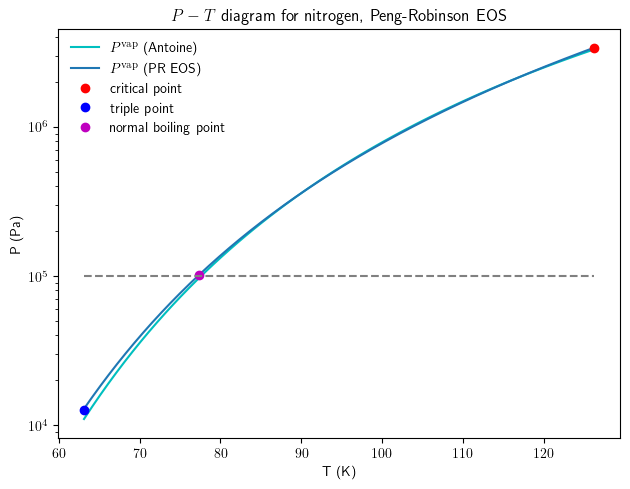

In [146]:
import seaborn as sns
import matplotlib.pyplot as plt
import matplotlib as mpl
mpl.rcParams["text.usetex"] = True

# Antoine equation given parameters A, B, and C
# Pressure is returned in Pa
def P_antoine(A, B, C, T):
    return 10**(A - B/(T + C))*100000

# Antoine equation parameters
# Valid temperature range in K
T_Antoine_min = 63.14
T_Antoine_max = 126
A = 3.7362
B = 264.651
C = -6.788

# Plot the Antoine equation
T = np.arange(T_Antoine_min, T_Antoine_max+1, 1)
plt.plot(T, P_antoine(A, B, C, T), "c", label=r"$P^\mathrm{vap}$ (Antoine)")

sns.lineplot(data=df_eq, x="T", y="P", label=r"$P^\mathrm{vap}$ (PR EOS)")
plt.xlabel("T (K)")
plt.ylabel("P (Pa)")
plt.yscale("log")
plt.tight_layout()

# Plot the critical point
plt.plot(Tc, Pc, "ro", label="critical point")

# Plot the triple point
plt.plot(T_triple, P_triple, "bo", label="triple point")

# Plot the normal boiling point (from Streng)
plt.plot(77.4, 101325, "mo", label="normal boiling point")

plt.title(r"$P-T$ diagram for nitrogen, Peng-Robinson EOS")
plt.legend(frameon=True, fancybox=True, edgecolor='none')

# Line at 1 bar
plt.plot([T_triple, Tc],[100000, 100000], linestyle = '--', color="gray")

plt.show()

We can also create a P-V diagram using the same dataframe:

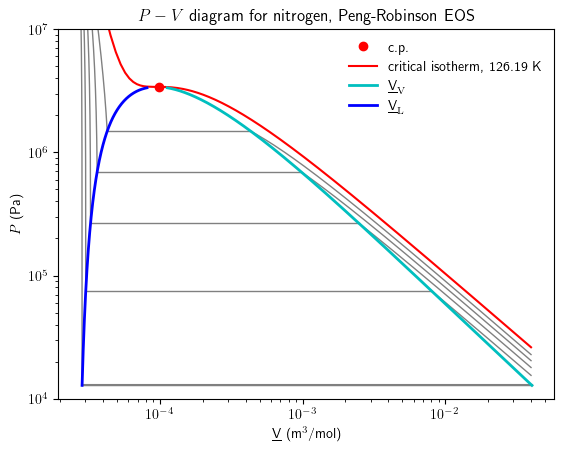

In [168]:
# This line can cause problems in Google Colab
import matplotlib as mpl
mpl.rcParams["text.usetex"] = True

# Plot (calculated) critical point
Vc = PR_Z(Pc,Tc,Pc,Tc,omega)*R*Tc/Pc
plt.plot(Vc, Pc, "ro", label="c.p.") 

# Add the critical isotherm
V = np.linspace(Vc/3,4e-2,10000)
plt.plot(V, PR_P(V,Tc,Pc,Tc,omega), color='red', linestyle='-',label=f"critical isotherm, {Tc} K")

# Plot the t.p. tie line
row_min_T = df_eq.loc[df_eq["T"].idxmin()]
vL = row_min_T["vL"]
vV = row_min_T["vV"]
P  = row_min_T["P"]
plt.plot([vL, vV], [P, P], color='gray', linestyle='-')

# Pick and plot 4 evenly spaced tie lines through the dataframe
idx = np.linspace(0, len(df_eq)/4*3, 5, dtype=int)
for i in idx:
    row = df_eq.iloc[i]
    vL, vV, P = row["vL"], row["vV"], row["P"]
    
    # Draw tie line
    plt.plot([vL, vV], [P, P], '-', linewidth=1, color='gray')

    # Plot the isotherm above the vapor line
    V = np.linspace(row["vV"],4e-2,1000)
    plt.plot(V, PR_P(V,row["T"],Pc,Tc,omega), color='gray', linestyle='-', linewidth=1)

    # Plot the isotherm below the liquid line
    V = np.linspace(row["vL"],2.8e-5,1000)
    plt.plot(V, PR_P(V,row["T"],Pc,Tc,omega), color='gray', linestyle='-', linewidth=1)
    

# Plot the vapor coexistence line
sns.lineplot(data=df_eq, x="vV", y="P", color="c", linewidth=2, label=r"$\underline{V}_\mathrm{V}$")

# Plot the liquid coexistence line
sns.lineplot(data=df_eq, x="vL", y="P", color="b", linewidth=2, label=r"$\underline{V}_\mathrm{L}$")

plt.ylim([1e4, 1e7])
plt.xscale("log")
plt.yscale("log")
plt.xlabel(r"$\underline{V}$ (m$^3$/mol)")
plt.ylabel(r"$P$ (Pa)")
plt.title('$P-V$ diagram for nitrogen, Peng-Robinson EOS')

plt.legend(frameon=True, fancybox=True, edgecolor='none')
#plt.tight_layout()

plt.show()

As we approach the critical point, it becomes more difficult to calculate the binodal. I used many points, which is inefficient, but gets us to 0.99*Pc.

Since we use a Pandas dataframe, we can easily generate a table of the results:

In [145]:
df_eq

,T,P,vL,vV
0,63.140000,1.283031e+04,0.000028,0.040580
1,63.171351,1.290334e+04,0.000028,0.040369
2,63.202703,1.297670e+04,0.000029,0.040159
3,63.234054,1.305040e+04,0.000029,0.039950
4,63.265406,1.312443e+04,0.000029,0.039743
...,...,...,...,...
1995,125.686024,3.319799e+06,0.000079,0.000116
1996,125.717376,3.324631e+06,0.000080,0.000115
1997,125.748727,3.329469e+06,0.000080,0.000114
1998,125.780079,3.334311e+06,0.000081,0.000114


Some additional things we can do include 

1. Plot the triple point isotherm 
1. Plotting tie lines on the VLE phase envelope and plotting isotherms around the binodal
2. Plotting $\ln P^\mathrm{vap}(T)$ versus $1/T$ and fitting the Antoine equation.

Plot $\ln P^\mathrm{vap}$ versus $1/T$:

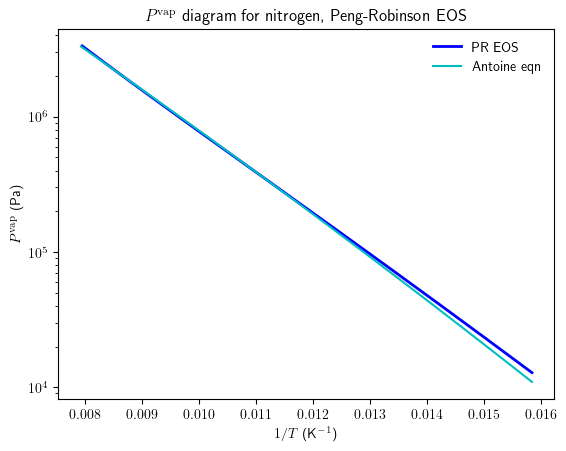

In [165]:
# Add 1/T to the dataframe:
df_eq['1_over_T'] = 1 / df_eq["T"]

# Plot the result
sns.lineplot(data=df_eq, x="1_over_T", y="P", color="b", linewidth=2, label="PR EOS")

# Add the Antoine equation to the plot
# Antoine equation given parameters A, B, and C
# Pressure is returned in Pa
def P_antoine(A, B, C, T):
    return 10**(A - B/(T + C))*100000

# Antoine equation parameters
# Valid temperature range in K
T_Antoine_min = 63.14
T_Antoine_max = 126
A = 3.7362
B = 264.651
C = -6.788

# Plot the Antoine equation
T = np.arange(T_Antoine_min, T_Antoine_max+1, 1)
plt.plot(1/T, P_antoine(A, B, C, T), "c", label="Antoine eqn")

#plt.xscale("log")
plt.yscale("log")
plt.xlabel(r"$1/T$ (K$^{-1}$)")
plt.ylabel(r"$P^\mathrm{vap}$ (Pa)")
plt.title(r'$P^\mathrm{vap}$ diagram for nitrogen, Peng-Robinson EOS')

plt.legend(frameon=True, fancybox=True, edgecolor='none')
#plt.tight_layout()

plt.show()